Классификация изображений с использованием Transfer Learning

**Вариант:** 1 (Классификация изображений)  
**Датасет:** Oxford Flowers 102  
**Архитектура:** ResNet18  


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


## Предобработка данных

Перед подачей изображений в нейронную сеть выполняются следующие преобразования:

- изменение размера изображений до 224×224
- случайное отражение (data augmentation)
- нормализация (по статистике ImageNet)

Это необходимо, так как:
- модель ResNet обучалась на изображениях размера 224×224
- нормализация ускоряет обучение

In [10]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
dataset = torchvision.datasets.Flowers102(
    root="./data",
    split="train",
    download=True,
    transform=transform
)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

## Архитектура модели

В работе используется модель ResNet18.

ResNet — это глубокая сверточная нейронная сеть с остаточными связями (skip connections), которые позволяют эффективно обучать глубокие модели.

Особенности:
- предобучена на датасете ImageNet
- используется как extractor признаков
- последний слой заменён под текущую задачу (102 класса)


In [11]:
model = torchvision.models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False


model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, 102)
)


for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

optimizer = optim.Adam(model.fc.parameters(), lr=0.0005)

In [12]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    return total_loss / len(loader), correct / total


def evaluate(model, loader, max_batches=50):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for i, (images, labels) in enumerate(loader):
            if i >= max_batches:
                break

            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return correct / total

Epoch 1: Loss=3.3559, Train Acc=0.2647, Val Acc=0.3578
Epoch 2: Loss=3.0776, Train Acc=0.3615, Val Acc=0.4412
Epoch 3: Loss=2.8726, Train Acc=0.4301, Val Acc=0.4853
Epoch 4: Loss=2.6725, Train Acc=0.4828, Val Acc=0.5539
Epoch 5: Loss=2.4849, Train Acc=0.5453, Val Acc=0.5980
Epoch 6: Loss=2.3057, Train Acc=0.5662, Val Acc=0.6127
Epoch 7: Loss=2.1630, Train Acc=0.6115, Val Acc=0.5882
Epoch 8: Loss=2.0719, Train Acc=0.6189, Val Acc=0.6520
Epoch 9: Loss=1.9073, Train Acc=0.6814, Val Acc=0.6471
Epoch 10: Loss=1.8532, Train Acc=0.6740, Val Acc=0.6422


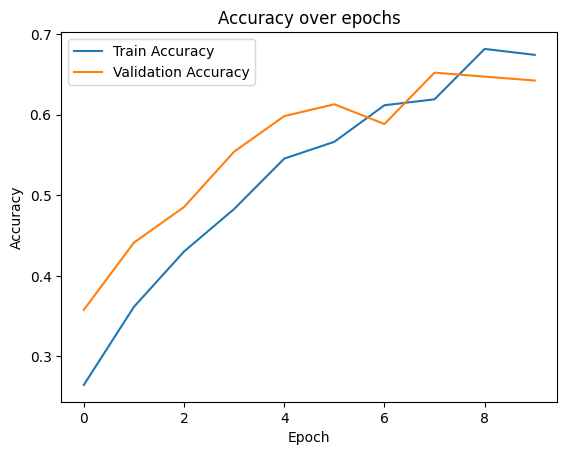

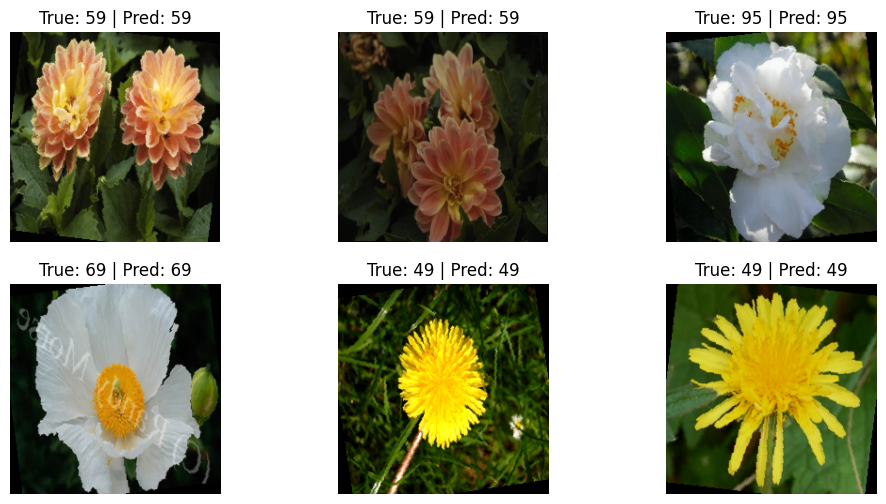

In [14]:
EPOCHS = 10

train_acc_history = []
val_acc_history = []

for epoch in range(EPOCHS):
    loss, train_acc = train_epoch(model, train_loader)
    val_acc = evaluate(model, val_loader)

    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    print(f"Epoch {epoch+1}: Loss={loss:.4f}, Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")


plt.plot(train_acc_history, label="Train Accuracy")
plt.plot(val_acc_history, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy over epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

dataiter = iter(val_loader)
images, labels = next(dataiter)

images = images.to(device)

outputs = model(images)
_, preds = torch.max(outputs, 1)

images = images.cpu()

plt.figure(figsize=(12, 6))

for i in range(6):
    plt.subplot(2, 3, i+1)

    img = images[i].permute(1, 2, 0).numpy()
    img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(f"True: {labels[i].item()} | Pred: {preds[i].item()}")
    plt.axis("off")

plt.show()